In [1]:
! pip install geopandas shapely fiona pyproj networkx

In [2]:
! pip install folium

In [4]:
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import fiona

In [5]:
file_path = r"../data/raw/OGIM_v1.1.gpkg"

In [6]:
layers = fiona.listlayers(file_path)

for layer in layers:
    print(layer)

Oil_and_Natural_Gas_Wells
Natural_Gas_Compressor_Stations
Gathering_and_Processing
Tank_Battery
Offshore_Platforms
LNG_Facilities
Crude_Oil_Refineries
Petroleum_Terminals
Injection_Disposal_and_Underground_Storage
Stations_Other
Equipment_and_Components
Oil_and_Natural_Gas_Production
Natural_Gas_Flaring_Detections
Oil_Natural_Gas_Pipelines
Oil_and_Natural_Gas_Fields
Oil_Natural_Gas_Basins
OGIM_v1_Data_Catalog


In [7]:
pipelines = gpd.read_file(file_path, layer="Oil_Natural_Gas_Pipelines", rows=20000)

fields = gpd.read_file(file_path, layer="Oil_and_Natural_Gas_Fields", rows=5000)

refineries = gpd.read_file(file_path, layer="Crude_Oil_Refineries", rows=500)

terminals = gpd.read_file(file_path, layer="Petroleum_Terminals", rows=500)
compressors = gpd.read_file(file_path, layer="Natural_Gas_Compressor_Stations")

In [8]:
print(pipelines.geometry.iloc[0])

LINESTRING (-66.0000011 45.25959729999987, -65.99011810000002 45.2456702, -65.99629169999999 45.243122799999824, -65.9969532 45.24213329999987, -65.9969429 45.24000009999985, -65.99774330000002 45.23898889999986, -65.9980784 45.234704399999885, -65.99789370000003 45.232647799999896, -65.99329920000004 45.22570219999989, -65.98864079999998 45.21532829999988)


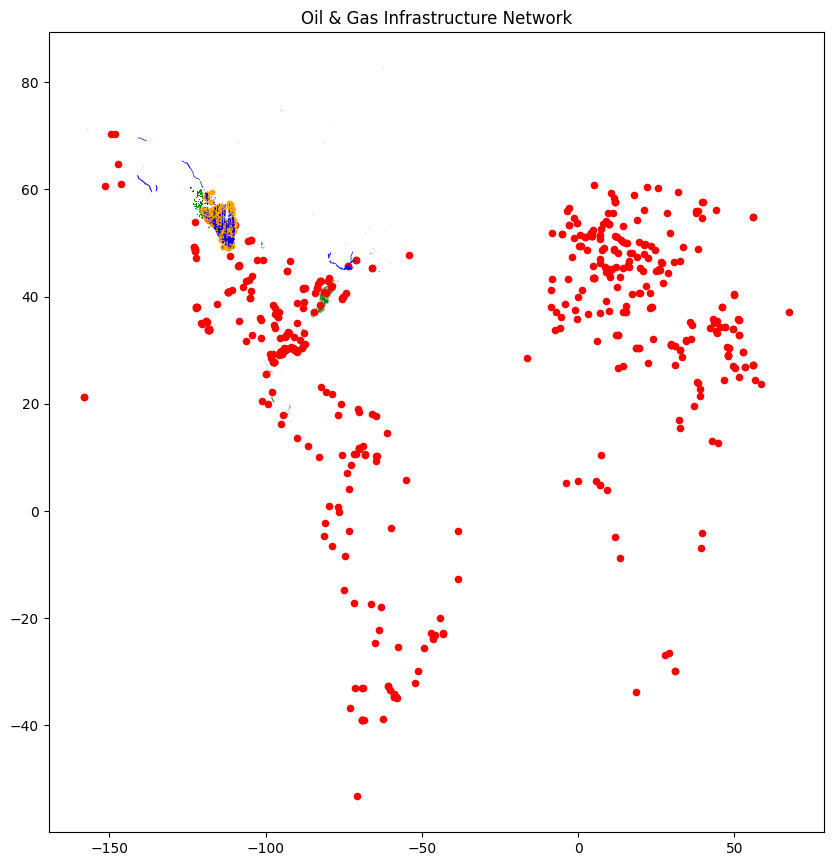

In [9]:
fig, ax = plt.subplots(figsize=(10,20))

pipelines.plot(ax=ax, color="blue", linewidth=0.5)
fields.plot(ax=ax, color="green", markersize=5)
refineries.plot(ax=ax, color="red", markersize=20)
terminals.plot(ax=ax, color="orange", markersize=10)

plt.title("Oil & Gas Infrastructure Network")
plt.show()

In [15]:
# G = nx.Graph()

# for idx, row in pipelines.iterrows():

#     geom = row.geometry

#     if geom is None:
#         continue

#     if geom.geom_type == "LineString":

#         coords = list(geom.coords)

#         for i in range(len(coords) - 1):

#             start = coords[i]
#             end = coords[i + 1]

#             G.add_edge(start, end)

#     elif geom.geom_type == "MultiLineString":

#         for line in geom.geoms:

#             coords = list(line.coords)

#             for i in range(len(coords) - 1):

#                 start = coords[i]
#                 end = coords[i + 1]

#                 G.add_edge(start, end)

In [16]:
from geopy.distance import geodesic

In [17]:
G = nx.Graph()

for idx, row in pipelines.iterrows():

    geom = row.geometry

    if geom is None:
        continue

    if geom.geom_type == "LineString":

        coords = list(geom.coords)

        for i in range(len(coords)-1):

            start = coords[i]
            end = coords[i+1]

            distance = geodesic((start[1],start[0]),(end[1],end[0])).km

            G.add_edge(start,end,weight=distance)

    elif geom.geom_type == "MultiLineString":

        for line in geom.geoms:

            coords = list(line.coords)

            for i in range(len(coords)-1):

                start = coords[i]
                end = coords[i+1]

                distance = geodesic((start[1],start[0]),(end[1],end[0])).km

                G.add_edge(start,end,weight=distance)

In [18]:
print("Nodes:", len(G.nodes))
print("Edges:", len(G.edges))

Nodes: 79874
Edges: 64793


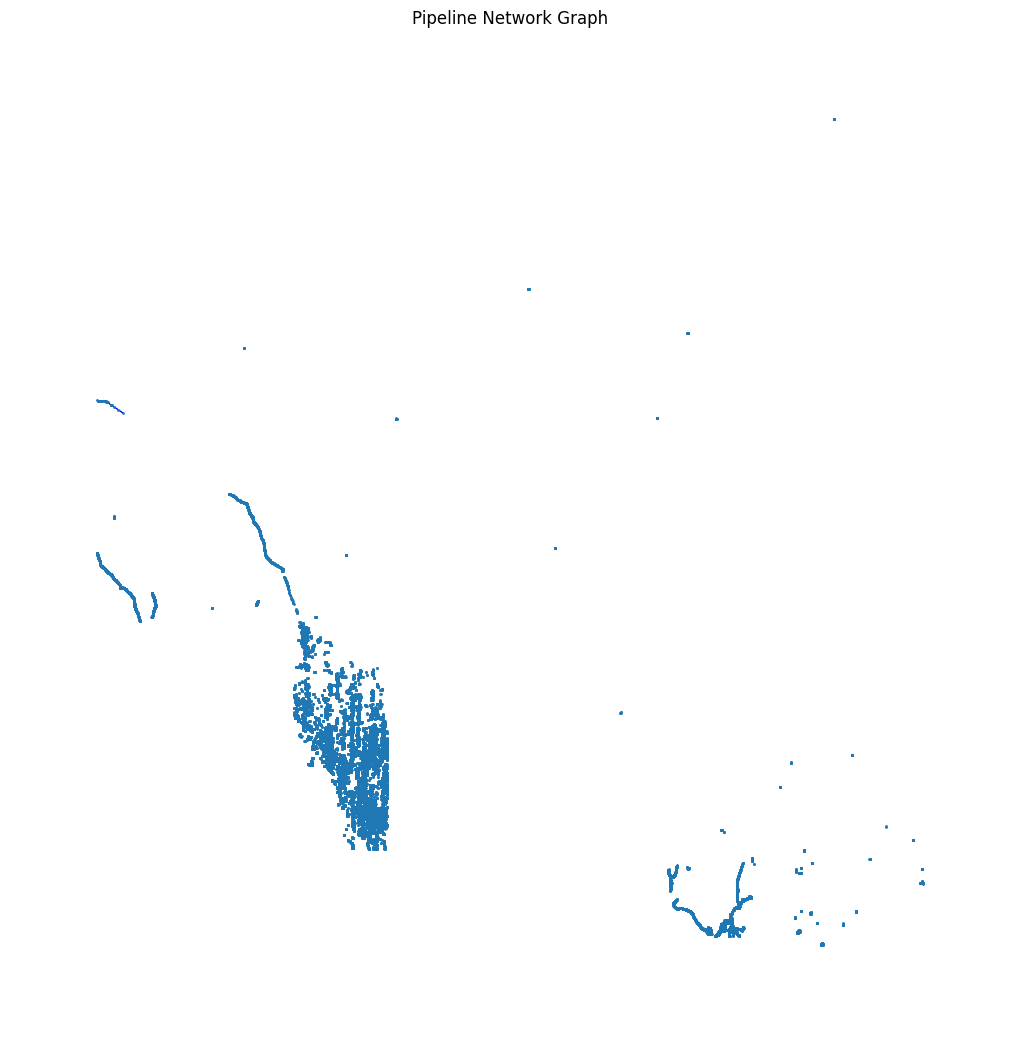

In [19]:
import matplotlib.pyplot as plt

pos = {node: node for node in G.nodes}

plt.figure(figsize=(10,10))
nx.draw(G, pos, node_size=1, edge_color="blue")
plt.title("Pipeline Network Graph")
plt.show()

In [21]:
print(len(pipelines))

20000


In [22]:
import networkx as nx

largest_component = max(nx.connected_components(G), key=len)

G_main = G.subgraph(largest_component).copy()

print("Nodes in main network:", len(G_main.nodes))

Nodes in main network: 370


In [23]:
import random

nodes = list(G_main.nodes)

start = random.choice(nodes)
end = random.choice(nodes)

route = nx.shortest_path(G_main, start, end, weight="weight")

distance = nx.shortest_path_length(G_main, start, end, weight="weight")

print("Start:", start)
print("End:", end)
print("Route Length:", len(route))
print("Total Distance:", distance)

Start: (-72.53810320000005, 47.71197509999929)
End: (-72.6321405, 47.04026909999954)
Route Length: 90
Total Distance: 82.4811164561559


In [24]:
components = list(nx.connected_components(G))

print("Number of pipeline networks:", len(components))

Number of pipeline networks: 15115


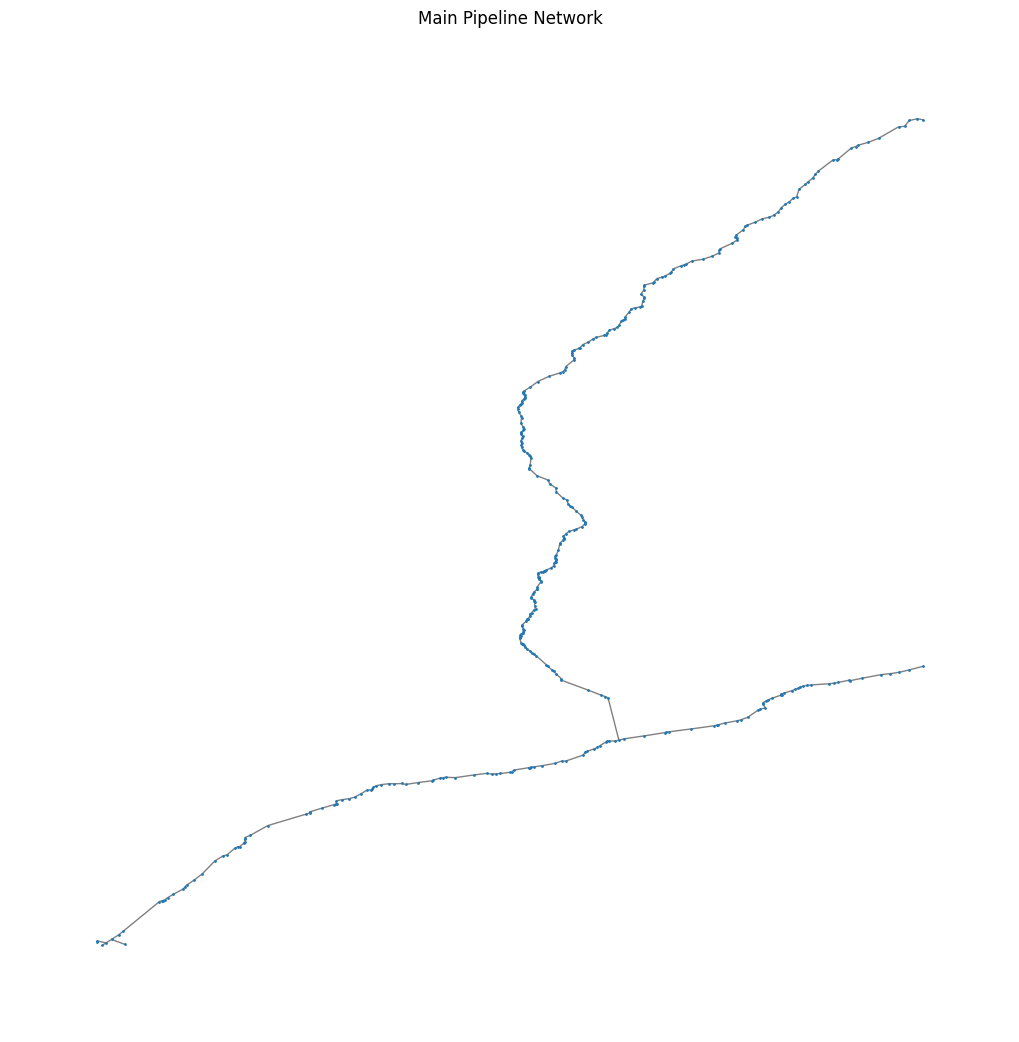

In [25]:
import matplotlib.pyplot as plt

pos = {node: node for node in G_main.nodes}

plt.figure(figsize=(10,10))
nx.draw(G_main, pos, node_size=1, edge_color="gray")
plt.title("Main Pipeline Network")
plt.show()

In [26]:
import networkx as nx

components = list(nx.connected_components(G))

print("Total pipeline networks:", len(components))

Total pipeline networks: 15115


In [27]:
largest_component = max(components, key=len)

G_main = G.subgraph(largest_component).copy()

print("Main network nodes:", len(G_main.nodes))
print("Main network edges:", len(G_main.edges))

Main network nodes: 370
Main network edges: 369


In [28]:
import random

nodes = list(G_main.nodes)

start = random.choice(nodes)
end = random.choice(nodes)

while start == end:
    end = random.choice(nodes)

print("Start:", start)
print("End:", end)

Start: (-72.9443458, 46.28096439999974)
End: (-72.58514229999997, 46.38567579999971)


In [29]:
route = nx.shortest_path(G_main, start, end, weight="weight")

distance = nx.shortest_path_length(G_main, start, end, weight="weight")

print("Route length:", len(route))
print("Transport distance:", distance, "km")

Route length: 31
Transport distance: 31.8929742673339 km


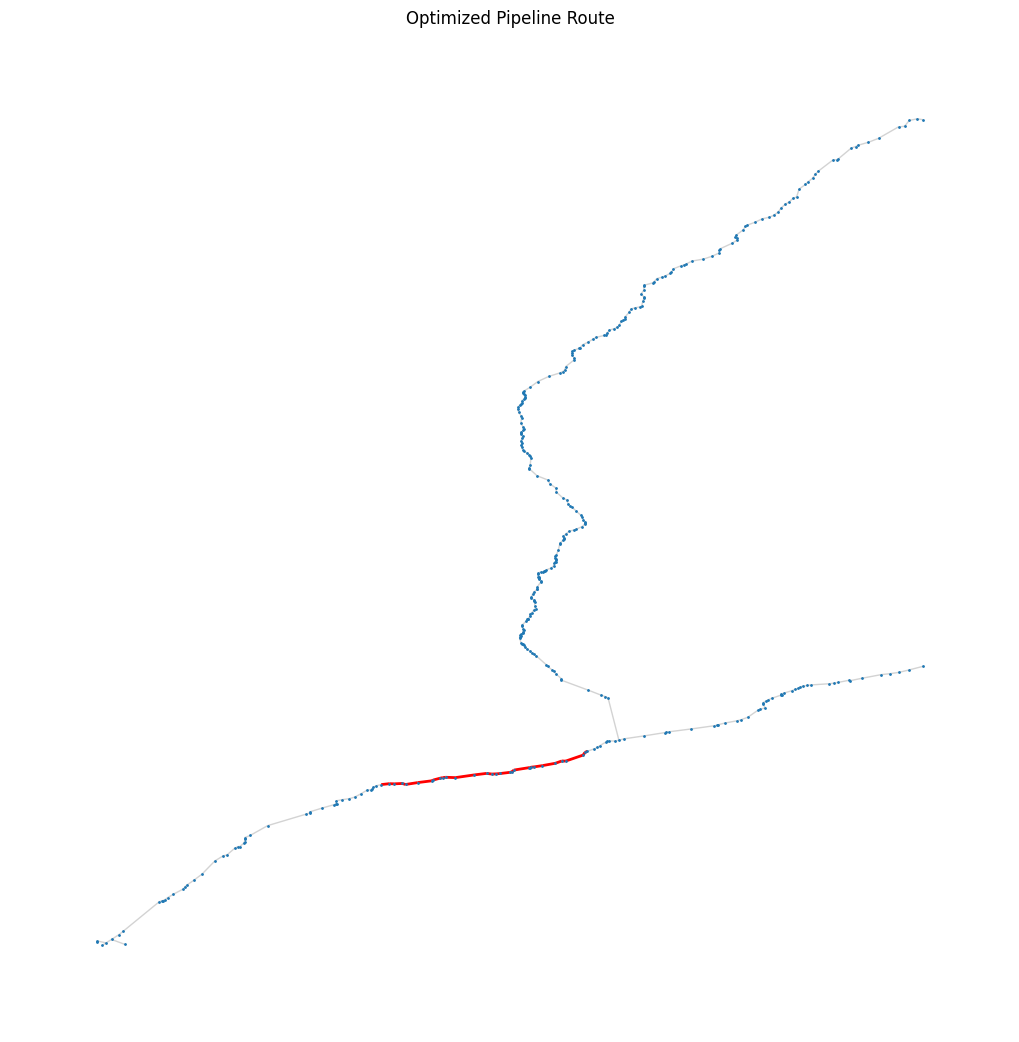

In [30]:
import matplotlib.pyplot as plt

pos = {node: node for node in G_main.nodes}

plt.figure(figsize=(10,10))

nx.draw(G_main, pos, node_size=1, edge_color="lightgray")

path_edges = list(zip(route, route[1:]))

nx.draw_networkx_edges(
    G_main,
    pos,
    edgelist=path_edges,
    edge_color="red",
    width=2
)

plt.title("Optimized Pipeline Route")
plt.show()

In [31]:
for u,v in G_main.edges():

    distance = G_main[u][v]["weight"]

    pipeline_tariff = 2.5
    compression_cost = random.uniform(0.2,0.5)
    emission_cost = random.uniform(0.05,0.2)

    cost = (
        distance * pipeline_tariff
        + distance * compression_cost
        + emission_cost
    )

    G_main[u][v]["cost"] = cost

In [32]:
nodes = list(G_main.nodes)

start = random.choice(nodes)
end = random.choice(nodes)

while start == end:
    end = random.choice(nodes)

print("Source:",start)
print("Destination:",end)

Source: (-72.2474453, 48.09110969999996)
Destination: (-72.67239419999997, 46.90160539999954)


In [33]:
route = nx.shortest_path(G_main,start,end,weight="cost")

cost = nx.shortest_path_length(G_main,start,end,weight="cost")

distance = nx.shortest_path_length(G_main,start,end,weight="weight")

print("Optimal route length:",len(route))
print("Transport distance:",distance,"km")
print("Transport cost:",cost)

Optimal route length: 166
Transport distance: 149.6432978405446 km
Transport cost: 448.0463383647016


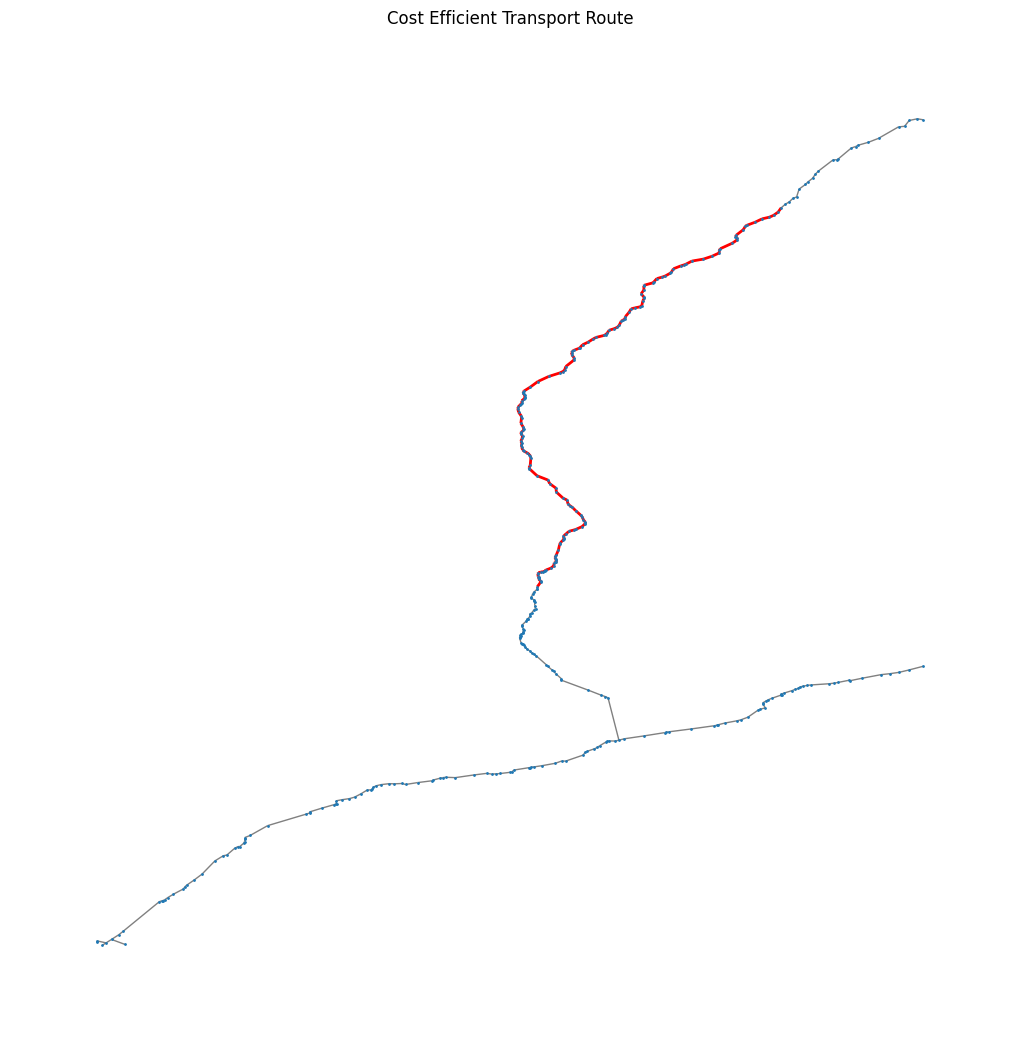

In [34]:
pos = {node:node for node in G_main.nodes}

plt.figure(figsize=(10,10))

nx.draw(G_main,pos,node_size=1,edge_color="gray")

path_edges = list(zip(route,route[1:]))

nx.draw_networkx_edges(
    G_main,
    pos,
    edgelist=path_edges,
    edge_color="red",
    width=2
)

plt.title("Cost Efficient Transport Route")
plt.show()

In [35]:
import pickle

with open("../data/processed/pipeline_network.pkl","wb") as f:
    pickle.dump(G_main,f)

In [36]:
import math

def nearest_node(graph, location):

    min_dist = float("inf")
    nearest = None

    for node in graph.nodes:

        lon, lat = node

        dist = math.sqrt((lon - location[0])**2 + (lat - location[1])**2)

        if dist < min_dist:
            min_dist = dist
            nearest = node

    return nearest

In [37]:
import networkx as nx

def optimize_transport(G, pickup, drop):

    # find nearest pipeline nodes
    start_node = nearest_node(G, pickup)
    end_node = nearest_node(G, drop)

    print("Nearest pipeline to pickup:", start_node)
    print("Nearest pipeline to drop:", end_node)

    # compute best route
    route = nx.shortest_path(G, start_node, end_node, weight="cost")

    total_cost = nx.shortest_path_length(G, start_node, end_node, weight="cost")

    total_distance = nx.shortest_path_length(G, start_node, end_node, weight="weight")

    return route, total_cost, total_distance

In [38]:
pickup_location = (-95.32, 29.76)   # oil well location
drop_location = (-96.11, 30.21)     # refinery location

In [39]:
route, cost, distance = optimize_transport(G_main, pickup_location, drop_location)

print("Route nodes:", len(route))
print("Total distance:", distance, "km")
print("Total cost:", cost)

Nearest pipeline to pickup: (-73.4400018, 45.78817469999983)
Nearest pipeline to drop: (-73.4400018, 45.78817469999983)
Route nodes: 1
Total distance: 0 km
Total cost: 0


In [64]:
pipelines = gpd.read_file(file_path, layer="Oil_Natural_Gas_Pipelines")

In [48]:

wells = gpd.read_file(file_path, layer="Oil_and_Natural_Gas_Wells", rows=2000)

refineries = gpd.read_file(file_path, layer="Crude_Oil_Refineries")

In [53]:
wells["coords"] = wells.geometry.apply(lambda x: (x.x, x.y))
refineries["coords"] = refineries.geometry.apply(lambda x: (x.x, x.y))

In [54]:
from geopy.distance import geodesic

def nearest_well(refinery_location):

    min_dist = float("inf")
    nearest = None

    for coord in wells["coords"]:

        dist = geodesic(
            (refinery_location[1], refinery_location[0]),
            (coord[1], coord[0])
        ).km

        if dist < min_dist:
            min_dist = dist
            nearest = coord

    return nearest

In [55]:
import math

def nearest_pipeline_node(graph, location):

    min_dist = float("inf")
    nearest = None

    for node in graph.nodes:

        dist = math.sqrt(
            (node[0]-location[0])**2 +
            (node[1]-location[1])**2
        )

        if dist < min_dist:
            min_dist = dist
            nearest = node

    return nearest

In [60]:
import networkx as nx

def optimize_transport(refinery_location):

    # find nearest oil well
    well = nearest_well(refinery_location)

    print("Nearest well:", well)

    # map well to pipeline
    start_node = nearest_pipeline_node(G_main, well)

    # map refinery to pipeline
    end_node = nearest_pipeline_node(G_main, refinery_location)

    route = nx.shortest_path(G_main, start_node, end_node, weight="cost")

    distance = nx.shortest_path_length(G_main, start_node, end_node, weight="weight")

    cost = nx.shortest_path_length(G_main, start_node, end_node, weight="cost")

    return route, well, distance, cost

In [61]:
from geopy.distance import geodesic

def compute_well_to_refinery_distance(well, refinery_location):

    distance = geodesic(
        (well[1], well[0]),           # latitude, longitude
        (refinery_location[1], refinery_location[0])
    ).km

    return distance

In [63]:
refinery_location = (-95.32, 29.74)

route, well, distance_pipeline, cost = optimize_transport(refinery_location)

well_to_refinery_distance = compute_well_to_refinery_distance(well, refinery_location)

print("Pickup well:", well)
print("Drop refinery:", refinery_location)

print("Direct well → refinery distance:", well_to_refinery_distance, "km")
print("Pipeline route distance:", distance_pipeline, "km")

print("Transport cost:", cost)
print("Route nodes:", len(route))

Nearest well: (-110.71477, 49.44133)
Pickup well: (-110.71477, 49.44133)
Drop refinery: (-95.32, 29.74)
Direct well → refinery distance: 2544.8559972768626 km
Pipeline route distance: 0 km
Transport cost: 0
Route nodes: 1


In [59]:
import folium

m = folium.Map(location=[route[0][1], route[0][0]], zoom_start=6)

for node in route:
    folium.CircleMarker(
        location=[node[1], node[0]],
        radius=2,
        color="red"
    ).add_to(m)

m